In [40]:
from nn_xors_2023_07_19 import output_dir
import pandas as pd
import seaborn as sns
import jsonlines
from pathlib import Path

In [41]:
def jsonlines_to_df(path: str | Path) -> pd.DataFrame:
    with jsonlines.open(path) as reader:
        return pd.DataFrame(reader)

In [42]:
df = jsonlines_to_df(output_dir / "results.jsonl")

In [43]:
df.to_csv("_results.csv", index=False)

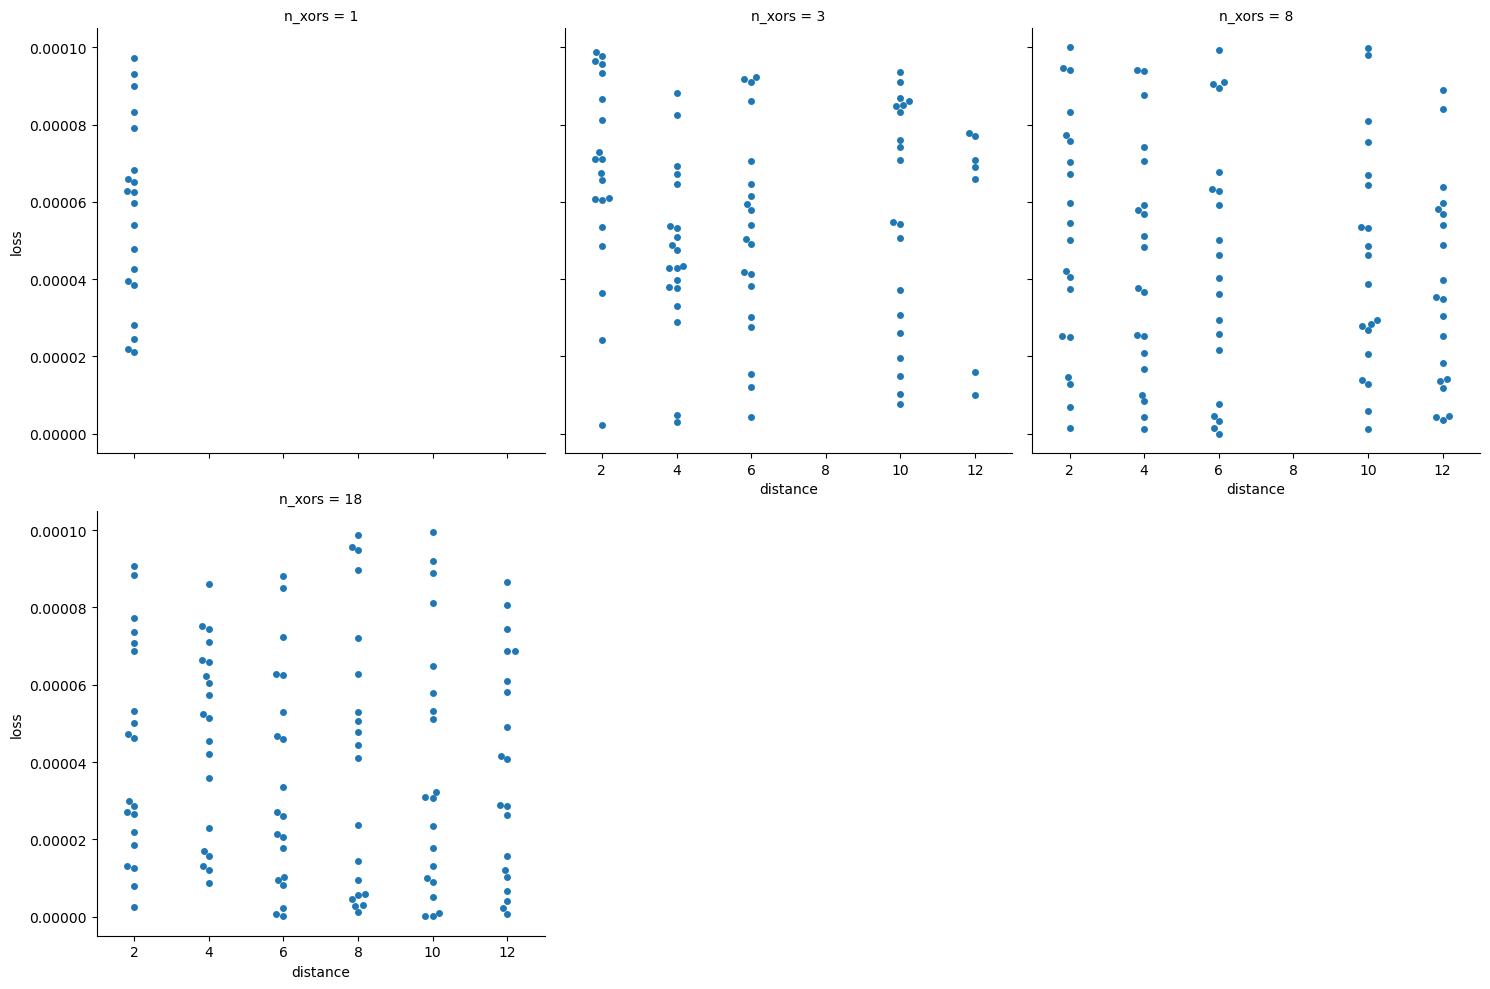

In [44]:
sns.catplot(
    data=df,
    x="distance",
    y="loss",
    col="n_xors",
    col_wrap=3,
    kind='swarm'
    #kind='line'
)

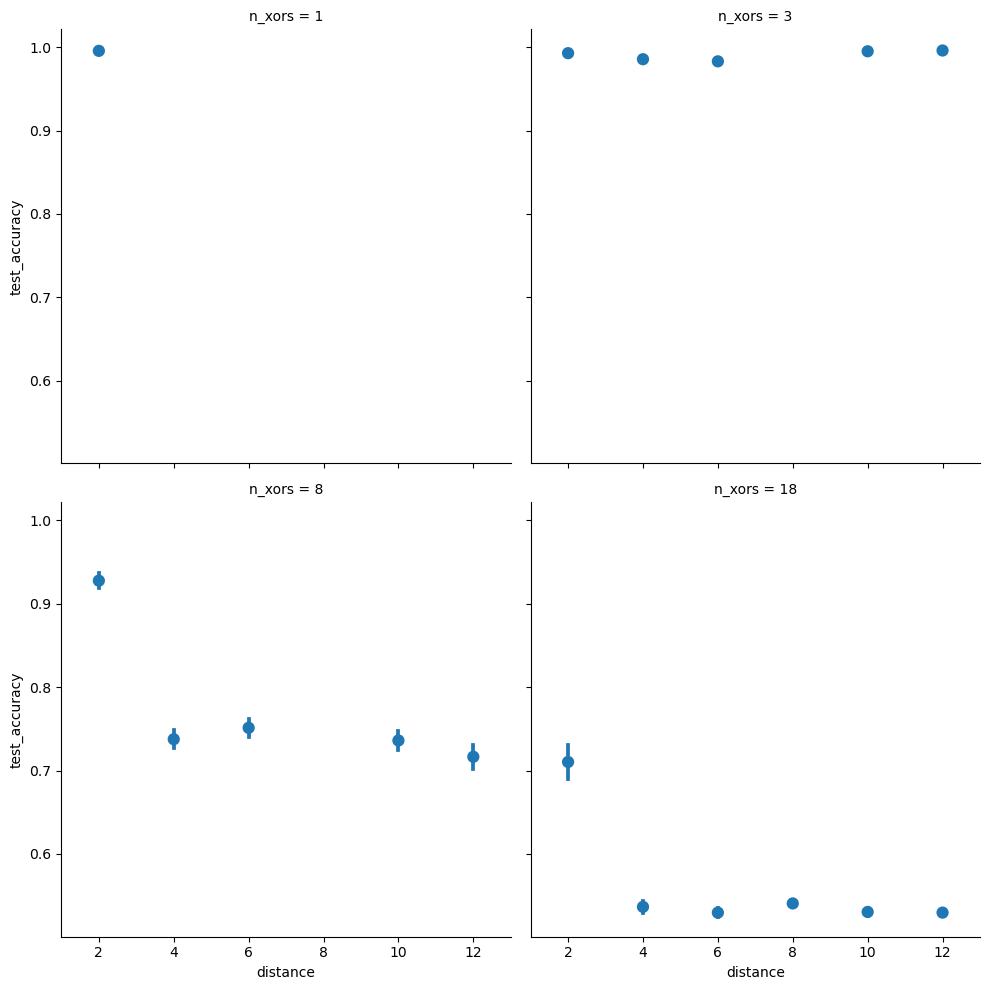

In [45]:
sns.catplot(
    data=df.query("train_accuracy > 0.95"),
    x="distance",
    y="test_accuracy",
    col="n_xors",
    kind="point",
    join=False,
    errorbar="se",
    col_wrap=2,
)

/nix/store/nwliiz7vza9ngv7ksmsn4a9ahz1l0ml3-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/nix/store/nwliiz7vza9ngv7ksmsn4a9ahz1l0ml3-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 45.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


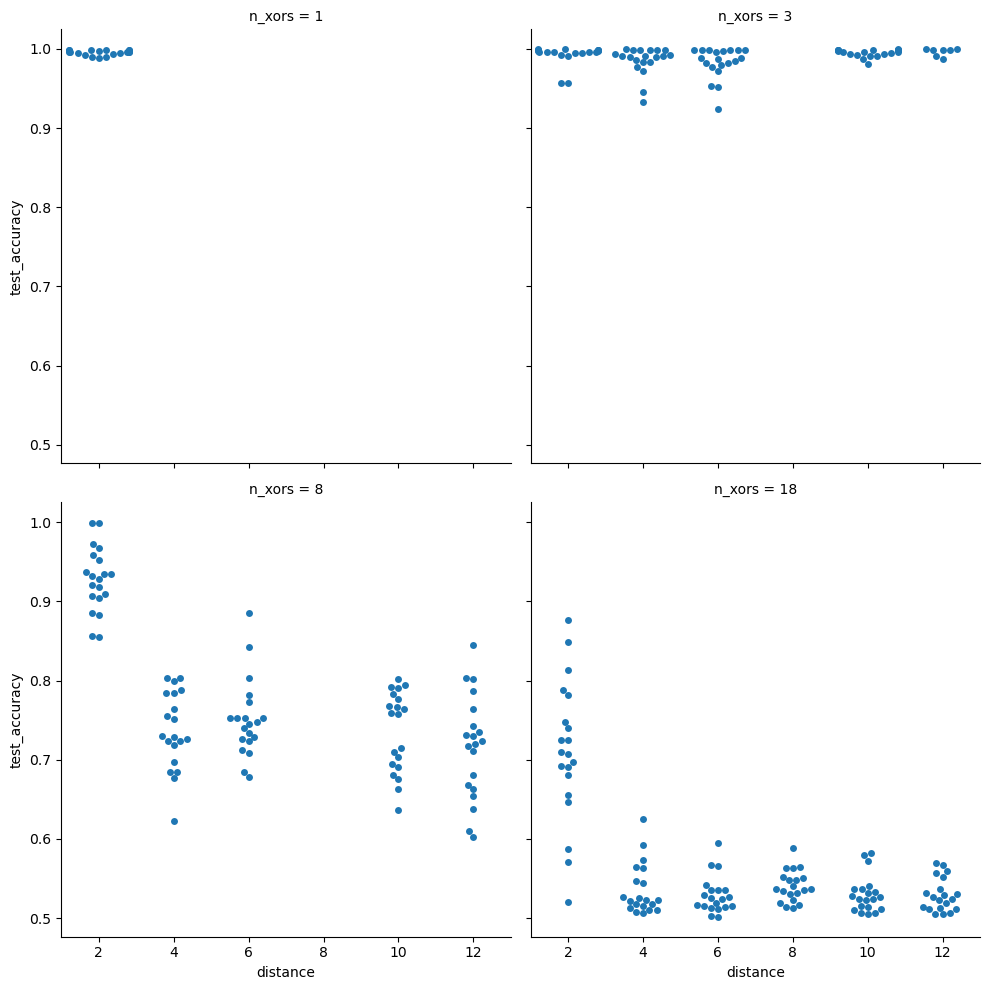

In [46]:
sns.catplot(
    data=df.query("train_accuracy > 0.95"),
    x="distance",
    y="test_accuracy",
    col="n_xors",
    kind="swarm",
    # kind="point",
    # join=False,
    errorbar="se",
    col_wrap=2,
)

In [47]:
df[df['epoch'] > 1000]

,n_xors,xor_hamming_weight,distance,run,eps_train,batch_size,n_hidden,model,loss,train_accuracy,test_accuracy,epoch


In [48]:
df.groupby(["n_xors", "distance"]).size()

n_xors  distance
1       2           20
3       2           20
        4           20
        6           20
        10          20
        12           7
8       2           20
        4           20
        6           20
        10          20
        12          20
18      2           20
        4           20
        6           20
        8           20
        10          20
        12          20
dtype: int64

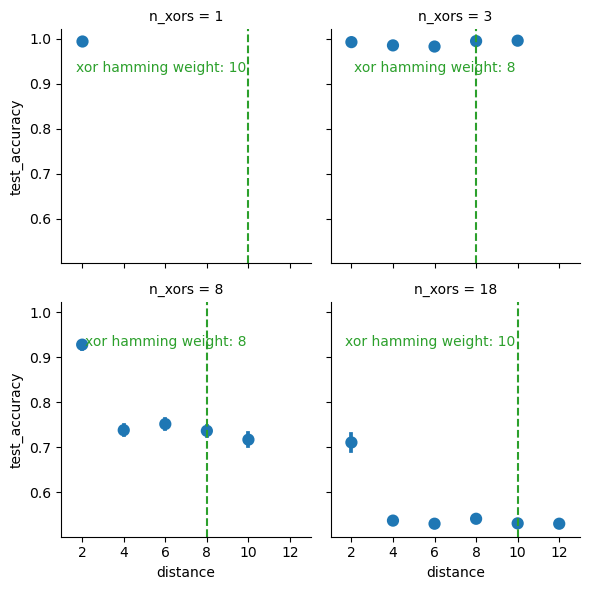

In [49]:
# Filter the data
df_filtered = df.query("train_accuracy > 0.95")

# Create a FacetGrid
g = sns.FacetGrid(df_filtered, col="n_xors", col_wrap=2)

# Add pointplots to each facet
g.map_dataframe(sns.pointplot, x="distance", y="test_accuracy", join=False, errorbar="se")

# Group the data by 'n_xors' and get the unique 'xor_hamming_weight' for each group
weights = df_filtered.groupby('n_xors')['xor_hamming_weight'].first()

# Get sorted unique distances
sorted_distances = sorted(df_filtered['distance'].unique())

# Iterate over each axis and add a vertical line and text
for ax in g.axes.flatten():
    n_xors = int(ax.get_title().split('=')[1])  # Extract the n_xors value from the title
    weight = weights[n_xors]  # Get the corresponding 'xor_hamming_weight' value
    weight_position = sorted_distances.index(weight)  # Get the position of the weight in the sorted distances
    ax.axvline(weight_position, color='C2', linestyle='--')  # Draw a vertical line
    ax.text(3.95, 0.95, f'xor hamming weight: {weight}', ha='right', va='top', color='C2')  # Add text
